# Revolut FAQ RAG Chatbot

RAG pipeline over Revolut help articles with LLM-as-a-judge evaluation.

In [1]:
import asyncio
import json
import os
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import AsyncOpenAI
from tqdm import tqdm

# Add project root to path
import sys
project_root = Path.cwd().parent
while not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.config import (
    BASE_URL, EMBED_MODEL, STUDENT_MODEL, TOP_K,
    CONCURRENCY, MAX_ROWS, SEED
)
from src.rag import (
    get_client, get_embedding_client,
    embed_texts, build_corpus_embeddings, retrieve as retrieve_from_emb
)
from src.generate_queries import generate_queries_with_resume
from src.vibe_check import validate_queries_with_resume
from src.judges import judge_with_resume

load_dotenv(dotenv_path=project_root / ".env")

DATA_DIR = project_root / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"

print(f"Configuration:")
print(f"  BASE_URL: {BASE_URL}")
print(f"  EMBED_MODEL: {EMBED_MODEL}")
print(f"  STUDENT_MODEL: {STUDENT_MODEL}")
print(f"  TOP_K: {TOP_K}")
print(f"  CONCURRENCY: {CONCURRENCY}")
print(f"  MAX_ROWS: {MAX_ROWS}")
print(f"  SEED: {SEED}")

Configuration:
  BASE_URL: https://api.openai.com/v1
  EMBED_MODEL: text-embedding-3-small
  STUDENT_MODEL: gpt-4o-mini
  TOP_K: 4
  CONCURRENCY: 16
  MAX_ROWS: None
  SEED: 42


## 1. Load articles

In [2]:
ARTICLES_PATH = DATA_DIR / "revolut_help_articles.jsonl"

articles = [json.loads(line) for line in ARTICLES_PATH.read_text().strip().split("\n")]
print(f"Loaded {len(articles)} articles")

# Show example
print(f"\nExample article:")
print(f"  Title: {articles[0]['title']}")
print(f"  Content length: {len(articles[0]['content_text'])} chars")

# Content length histogram
content_lengths = [len(a['content_text']) for a in articles]
print(f"\nContent length stats:")
print(f"  Mean: {np.mean(content_lengths):.0f}")
print(f"  Median: {np.median(content_lengths):.0f}")
print(f"  Min: {min(content_lengths)}")
print(f"  Max: {max(content_lengths)}")

Loaded 786 articles

Example article:
  Title: How can I see my cashflow analytics?
  Content length: 814 chars

Content length stats:
  Mean: 1209
  Median: 1118
  Min: 75
  Max: 4668


## 2. Embed all articles

In [3]:
corpus_embeddings, articles = await build_corpus_embeddings()
print(f"Embeddings shape: {corpus_embeddings.shape}")

Loading cached embeddings from /Users/veniamin/Projects/chatbot-evals-ai/data/outputs/corpus_emb.npz
Embeddings shape: (786, 1536)


## 3. Retrieval

In [4]:
async def retrieve(query_text: str, k: int = TOP_K):
    """Retrieve top-k articles for a query."""
    client = get_embedding_client()
    response = await client.embeddings.create(model=EMBED_MODEL, input=query_text)
    query_emb = np.array(response.data[0].embedding)
    
    return retrieve_from_emb(query_emb, corpus_embeddings, articles, top_k=k)

retrieve() function defined


## 4. Single-turn chat

In [5]:
system_prompt = """You are a Revolut customer support assistant. Answer questions using only the provided articles.

If the answer is not in the articles, say "I don't have enough information to help with that."

Be concise and practical. Reference specific steps when relevant."""

async def ask(query: str) -> tuple[str, list]:
    """Answer a query using RAG."""
    retrieved = await retrieve(query)
    
    context = "\n\n".join([
        f"Article: {r['title']}\n{r['content']}"
        for r in retrieved
    ])
    
    prompt = f"""{system_prompt}

Customer question:
{query}

Relevant articles:
{context}

Answer:"""
    
    client = get_client()
    response = await client.chat.completions.create(
        model=STUDENT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=600
    )
    
    return response.choices[0].message.content.strip(), retrieved

System prompt loaded


## 5. Try it

In [6]:
# In-scope question
question1 = "How do I reset my PIN in the Revolut app?"
answer1, retrieved1 = await ask(question1)

print(f"Q: {question1}")
print(f"A: {answer1}")
print(f"\nRetrieved:")
for r in retrieved1:
    print(f"  - {r['title']} (score: {r['score']:.3f})")

Q: How do I reset my PIN in the Revolut app?
A: To reset your PIN in the Revolut app, you can change your PIN at any ATM that has the 'PIN services' feature. Simply visit an ATM, select the option to change your PIN, and follow the prompts. 

If you have exceeded your PIN attempts and need to unblock your card, you can do so in the app by following these steps:
1. Go to 'Home' on the bottom menu.
2. Tap the cards icon in the top right corner.
3. Select the card you need to unblock.
4. Tap 'Settings'.
5. Select 'Unblock PIN/CVV'.

If you need further assistance, please let us know.

Retrieved:
  - Finding the card PIN (score: 0.720)
  - Problems with my card PIN (score: 0.701)
  - Change passcode (score: 0.689)
  - Change my phone number (score: 0.649)


In [7]:
# Out-of-scope question
question2 = "What's the best way to transfer money to a Monzo account?"
answer2, retrieved2 = await ask(question2)

print(f"Q: {question2}")
print(f"A: {answer2}")
print(f"\nRetrieved:")
for r in retrieved2:
    print(f"  - {r['title']} (score: {r['score']:.3f})")

Q: What's the best way to transfer money to a Monzo account?
A: To transfer money to a Monzo account, you can use a regular bank transfer or an easy bank transfer from your Revolut account. Here are the steps for each method:

### Regular Bank Transfer:
1. Share your Revolut account details with your external bank.
2. Initiate the transfer through your external bank.
3. Once the transfer is completed, you'll receive a notification in-app.

### Easy Bank Transfer:
1. Go to 'Home' on the bottom menu.
2. Tap 'Add money'.
3. Enter the amount you wish to transfer.
4. Choose 'Easy bank transfer' as your payment method.
5. Set the currency to GBP.
6. Follow the on-screen prompts and approve the transfer in your external bank app or website.

Remember, the transfer time may vary, and you can check the estimated arrival date using the in-app tool.

Retrieved:
  - Add money with a bank transfer (score: 0.510)
  - Receiving money to my Revolut card (score: 0.504)
  - Add money with an easy bank t

## 6. Synthetic dataset

In [8]:
# Load seeds
personas = [json.loads(line) for line in (project_root / "seeds/personas.jsonl").read_text().strip().split("\n")]
problems = [json.loads(line) for line in (project_root / "seeds/problems.jsonl").read_text().strip().split("\n")]
modifiers = [json.loads(line) for line in (project_root / "seeds/modifiers.jsonl").read_text().strip().split("\n")]

print(f"Seeds loaded:")
print(f"  Personas: {len(personas)}")
print(f"  Problems: {len(problems)}")
print(f"  Modifiers: {len(modifiers)}")

# Create ID->alias mappings (use ID as alias since no separate alias field)
persona_map = {p['id']: p['id'] for p in personas}
problem_map = {pr['id']: pr['id'] for pr in problems}
modifier_map = {m['id']: m['id'] for m in modifiers}

# Display seed tables
personas_df = pd.DataFrame(personas)
print(f"\nPersonas:")
print(personas_df.head())

problems_df = pd.DataFrame(problems)
print(f"\nProblems:")
print(problems_df.head())

modifiers_df = pd.DataFrame(modifiers)
print(f"\nModifiers:")
print(modifiers_df)

Seeds loaded:
  Personas: 10
  Problems: 25
  Modifiers: 6

Personas:
                          id  \
0      uk_freelance_designer   
1  non_native_english_worker   
2    elderly_first_time_user   
3             student_abroad   
4       small_business_owner   

                                         description  
0  Freelance graphic designer in Manchester, UK. ...  
1  Warehouse worker in Warsaw, 30 years old. Move...  
2  Retired teacher in Dublin, 68 years old. First...  
3  Exchange student in Lisbon, 21 years old. Orig...  
4  Cafe owner in Birmingham, 45 years old. Uses R...  

Problems:
                              id                                 title  \
0         verify_identity_failed   Identity verification keeps failing   
1  pending_verification_too_long         Verification pending for days   
2        card_not_working_abroad  Card stopped working while traveling   
3           virtual_card_missing        Can't find virtual card option   
4          apple_pay_not_w

In [9]:
# Generate synthetic queries with resume
grid = [(p, pr, m) for p in personas for pr in problems for m in modifiers]

queries_file = OUTPUTS_DIR / "synthetic_queries.csv"

if queries_file.exists():
    existing = pd.read_csv(queries_file)
    print(f"Queries resume: {len(existing)} done, {len(grid) - len(existing)} missing")
else:
    print("Queries resume: 0 done, all missing")
    await generate_queries_with_resume(grid, queries_file)

queries_df = pd.read_csv(queries_file)
print(f"\nGenerated {len(queries_df)} queries")
print(queries_df.head())

Queries resume: 1500 done, 0 missing

Generated 1500 queries
              persona_id              problem_id  \
0  uk_freelance_designer  verify_identity_failed   
1  uk_freelance_designer  verify_identity_failed   
2  uk_freelance_designer  verify_identity_failed   
3  uk_freelance_designer  verify_identity_failed   
4  uk_freelance_designer  verify_identity_failed   

                    modifier_id  \
0                         empty   
1      poor_internet_connection   
2         anxious_security_fear   
3           angry_after_waiting   
4  typing_from_phone_with_typos   

                                               query  
0  Hi there, I submitted my documents for verific...  
1  Hi, I submitted my docs for verification but g...  
2  Hi there, I've submitted my verification docum...  
3  I've submitted my verification documents multi...  
4  Hey, I submitted my docs for verification but ...  


In [10]:
# Vibe check with resume
validated_file = OUTPUTS_DIR / "validated_queries.csv"

if validated_file.exists():
    existing = pd.read_csv(validated_file)
    print(f"Vibe check resume: {len(existing)} done, {len(queries_df) - len(existing)} missing")
    validated_df = existing
else:
    print("Vibe check resume: 0 done, all missing")
    await validate_queries_with_resume(queries_file, validated_file, personas, problems, modifiers)
    validated_df = pd.read_csv(validated_file)

# Add alias columns (using ID as alias)
validated_df['persona_alias'] = validated_df['persona_id'].map(persona_map)
validated_df['modifier_alias'] = validated_df['modifier_id'].map(modifier_map)
print(f"\nValidated {len(validated_df)} queries")
print(validated_df.head())

Vibe check resume: 1500 done, 0 missing

Validated 1500 queries
              persona_id                     problem_id  \
0  uk_freelance_designer         verify_identity_failed   
1  uk_freelance_designer  pending_verification_too_long   
2  uk_freelance_designer        card_not_working_abroad   
3  uk_freelance_designer           virtual_card_missing   
4  uk_freelance_designer          apple_pay_not_working   

                 modifier_id  \
0  non_native_broken_english   
1  non_native_broken_english   
2  non_native_broken_english   
3  non_native_broken_english   
4  non_native_broken_english   

                                               query  looks_human_mobile  \
0  Hello, I submitted my documents for verify but...               False   
1  I finish verification 3 days ago but my accoun...                True   
2  My card not working in Thailand. I no change s...                True   
3  Hi, I need help. I want to make virtual card f...                True   
4  Hello

Acceptance rate by modifier:
modifier_alias
typing_from_phone_with_typos    0.768000
poor_internet_connection        0.738956
angry_after_waiting             0.726908
anxious_security_fear           0.710843
empty                           0.698795
non_native_broken_english       0.677165
Name: passed, dtype: float64


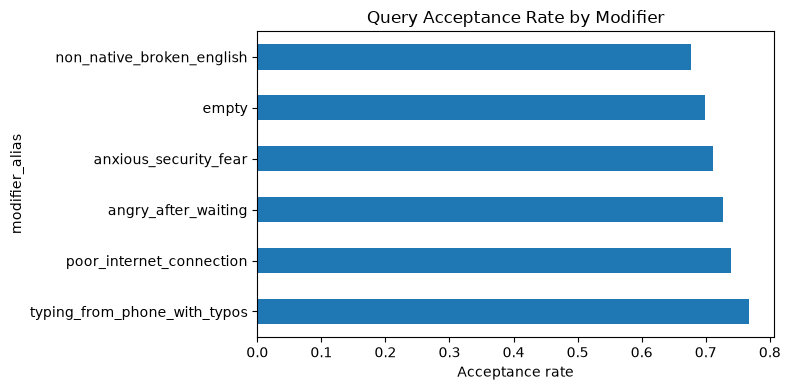

In [11]:
# Acceptance rate by modifier
modifier_rates = validated_df.groupby("modifier_alias")["passed"].mean().sort_values(ascending=False)
print("Acceptance rate by modifier:")
print(modifier_rates)

plt.figure(figsize=(8, 4))
modifier_rates.plot(kind="barh")
plt.xlabel("Acceptance rate")
plt.title("Query Acceptance Rate by Modifier")
plt.tight_layout()
plt.show()

Acceptance rate by persona:
persona_alias
busy_parent_on_mobile        1.000000
student_abroad               0.993333
frequent_traveler            0.980000
non_native_english_worker    0.947368
crypto_day_trader            0.946667
gig_economy_courier          0.946667
small_business_owner         0.873333
uk_freelance_designer        0.600000
elderly_first_time_user      0.000000
privacy_conscious_user       0.000000
Name: passed, dtype: float64


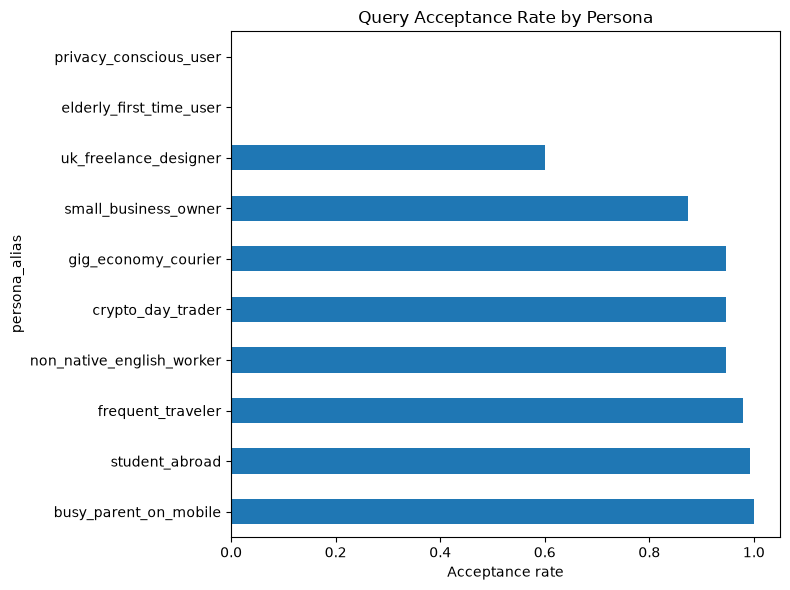

In [12]:
# Acceptance rate by persona
persona_rates = validated_df.groupby("persona_alias")["passed"].mean().sort_values(ascending=False)
print("Acceptance rate by persona:")
print(persona_rates)

plt.figure(figsize=(8, 6))
persona_rates.plot(kind="barh")
plt.xlabel("Acceptance rate")
plt.title("Query Acceptance Rate by Persona")
plt.tight_layout()
plt.show()

In [13]:
# Rejected examples
rejected = validated_df[validated_df["passed"] == False]
print(f"Rejected examples: {len(rejected)}")
if len(rejected) > 0:
    print(rejected["reasoning"].head(10).tolist())

Rejected examples: 420
["The query is too formal and polished for a non-native speaker with limited English proficiency, lacking the expected grammar mistakes and simpler vocabulary. Additionally, it does not reflect the persona's communication style, which would include more informal language and possibly Britishisms.", "The query is mostly informal and plausible for mobile typing, but it does not match the persona's communication style. The user is described as having limited English proficiency and making grammar mistakes, which is not reflected in the query. The query is too polished and lacks the expected errors and simplicity in vocabulary that would align with the persona's characteristics.", "The query is informal and plausible for mobile typing, and it addresses the user's problem. However, it does not match the persona's communication style, as the user is described as having limited English proficiency and making grammar mistakes, while the query is relatively clear and well

## 7. RAG over dataset

In [14]:
# Run RAG pipeline with resume
rag_output_file = OUTPUTS_DIR / "rag_outputs.csv"

if rag_output_file.exists():
    existing = pd.read_csv(rag_output_file)
    print(f"RAG resume: {len(existing)} done, {len(validated_df) - len(existing)} missing")
    # Use checkpoint data instead of reprocessing
    rag_df = existing
else:
    print("RAG resume: 0 done, all missing")
    from src.rag import run_rag
    rag_df = await run_rag(validated_df)

print(f"\nRAG complete: {len(rag_df)} answers")
print(rag_df.head())

RAG resume: 1080 done, 420 missing

RAG complete: 1080 answers
              persona_id              problem_id  \
0  uk_freelance_designer  transfer_pending_stuck   
1  uk_freelance_designer  transfer_pending_stuck   
2  uk_freelance_designer  transfer_pending_stuck   
3  uk_freelance_designer  transfer_pending_stuck   
4  uk_freelance_designer  transfer_pending_stuck   

                    modifier_id  \
0                         empty   
1      poor_internet_connection   
2         anxious_security_fear   
3           angry_after_waiting   
4  typing_from_phone_with_typos   

                                               query  looks_human_mobile  \
0  Hi there, I've sent some money to my mate two ...                True   
1  Hey, I sent money to my mate two days ago and ...                True   
2  I sent money to my mate two days ago and it’s ...                True   
3  I've sent money to my mate two days ago and it...                True   
4  Hey, I sent some cash to my ma

In [15]:
# Retrieval hit rate (how often we retrieved relevant content)
# This is a simplified metric - in production you'd track article IDs
print(f"RAG output columns: {rag_df.columns.tolist()}")
print(f"\nSample:")
print(rag_df[['query', 'answer', 'retrieved_titles']].head())

RAG output columns: ['persona_id', 'problem_id', 'modifier_id', 'query', 'looks_human_mobile', 'not_ai_slop', 'single_language', 'matches_problem', 'matches_persona', 'no_pii', 'passed', 'reasoning', 'answer', 'retrieved_ids', 'retrieved_titles', 'retrieved_scores', 'gold_article_retrieved']

Sample:
                                               query  \
0  Hi there, I've sent some money to my mate two ...   
1  Hey, I sent money to my mate two days ago and ...   
2  I sent money to my mate two days ago and it’s ...   
3  I've sent money to my mate two days ago and it...   
4  Hey, I sent some cash to my mate two days ago ...   

                                              answer  \
0  Your transfer may be pending for several reaso...   
1  Your transfer may still be pending for several...   
2  The delay in your transfer could be due to sev...   
3  Your transfer may still be pending due to seve...   
4  Your transfer may still be pending for several...   

                        

## 8. LLM-as-a-Judge Evaluation

In [16]:
# Load judge prompts
judge_dir = project_root / "prompts/judges"
judge_prompts = {
    "groundedness": (judge_dir / "groundedness.txt").read_text().strip(),
    "relevance": (judge_dir / "relevance.txt").read_text().strip(),
    "completeness": (judge_dir / "completeness.txt").read_text().strip(),
    "clarity": (judge_dir / "clarity.txt").read_text().strip(),
    "tone_empathy": (judge_dir / "tone_empathy.txt").read_text().strip(),
    "safety": (judge_dir / "safety.txt").read_text().strip()
}

print(f"Loaded {len(judge_prompts)} judges")

Loaded 6 judges


In [17]:
# Run judges with resume
eval_file = OUTPUTS_DIR / "eval_results.csv"

if eval_file.exists():
    existing = pd.read_csv(eval_file)
    print(f"Judges resume: {len(existing)} done, {len(rag_df) - len(existing)} missing")
    eval_df = existing
else:
    print("Judges resume: 0 done, all missing")
    await judge_with_resume(rag_output_file, eval_file)
    eval_df = pd.read_csv(eval_file)

# Add alias columns (using ID as alias)
eval_df['persona_alias'] = eval_df['persona_id'].map(persona_map)
eval_df['modifier_alias'] = eval_df['modifier_id'].map(modifier_map)
print(f"Evaluated {len(eval_df)} responses")
print(eval_df.head())

Judges resume: 1080 done, 0 missing
Evaluated 1080 responses
              persona_id                     problem_id  \
0  uk_freelance_designer  pending_verification_too_long   
1  uk_freelance_designer  pending_verification_too_long   
2  uk_freelance_designer  pending_verification_too_long   
3  uk_freelance_designer  pending_verification_too_long   
4  uk_freelance_designer        card_not_working_abroad   

                    modifier_id  \
0                         empty   
1         anxious_security_fear   
2           angry_after_waiting   
3  typing_from_phone_with_typos   
4         anxious_security_fear   

                                               query  looks_human_mobile  \
0  Hi there, I completed my verification 3 days a...                True   
1  Hi there, I've completed my verification three...                True   
2  I've completed my verification 3 days ago and ...                True   
3  Hey mate, I did the verification thing 3 days ...                T

Overall LLM-as-a-judge pass rates:
  relevance: 78.2%
  completeness: 74.0%
  actionability: 67.8%
  safety_compliance: 38.1%
  groundedness: 19.3%
  tone_empathy: 0.4%


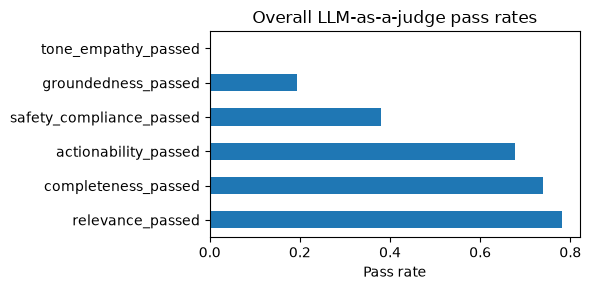

In [18]:
# Pass rate table
judge_cols = [c for c in eval_df.columns if c.endswith("_passed")]
pass_rates = eval_df[judge_cols].mean().sort_values(ascending=False)

print("Overall LLM-as-a-judge pass rates:")
for judge, rate in pass_rates.items():
    print(f"  {judge.replace('_passed', '')}: {rate:.1%}")

plt.figure(figsize=(6, 3))
pass_rates.plot(kind="barh")
plt.xlabel("Pass rate")
plt.title("Overall LLM-as-a-judge pass rates")
plt.tight_layout()
plt.show()

## 9. Metric analysis

In [19]:
# Target threshold analysis
print("Pass rate vs 80% threshold:")
for judge, rate in pass_rates.items():
    status = "PASS" if rate >= 0.8 else "FAIL"
    print(f"  {judge.replace('_passed', '')}: {rate:.1%} ({status})")

Pass rate vs 80% threshold:
  relevance: 78.2% (FAIL)
  completeness: 74.0% (FAIL)
  actionability: 67.8% (FAIL)
  safety_compliance: 38.1% (FAIL)
  groundedness: 19.3% (FAIL)
  tone_empathy: 0.4% (FAIL)


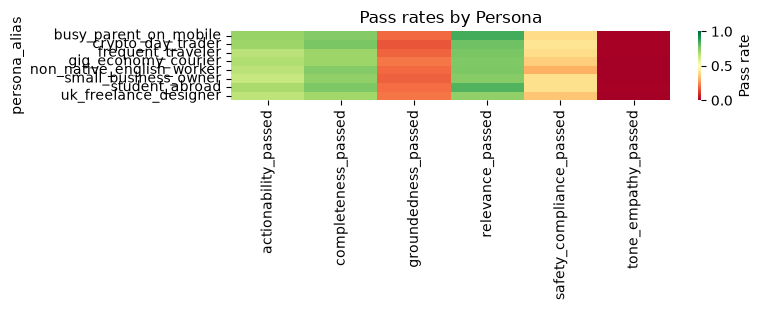

In [20]:
# Heatmap: criterion x persona
pivot_persona = eval_df.pivot_table(
    values=judge_cols,
    index="persona_alias",
    aggfunc="mean"
)

plt.figure(figsize=(8, len(pivot_persona) * 0.4))
sns.heatmap(pivot_persona, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.title("Pass rates by Persona")
plt.tight_layout()
plt.show()

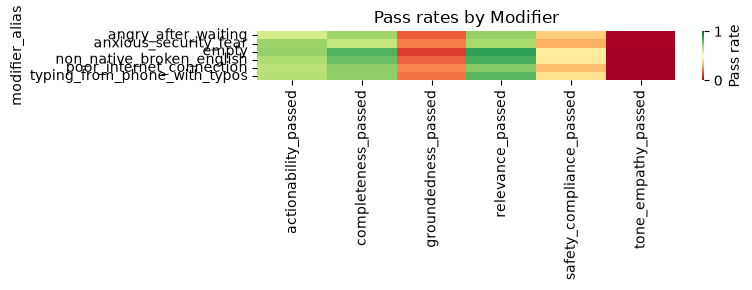

In [21]:
# Heatmap: criterion x modifier
pivot_modifier = eval_df.pivot_table(
    values=judge_cols,
    index="modifier_alias",
    aggfunc="mean"
)

plt.figure(figsize=(8, len(pivot_modifier) * 0.5))
sns.heatmap(pivot_modifier, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.title("Pass rates by Modifier")
plt.tight_layout()
plt.show()

In [22]:
# Worst slices (n >= 3)
slice_cols = ['persona_alias', 'modifier_alias']
slice_stats = eval_df.groupby(slice_cols)[judge_cols].mean()
slice_stats['n'] = eval_df.groupby(slice_cols).size()
slice_stats = slice_stats[slice_stats['n'] >= 3]

# Find worst performing slice for each judge
print("Worst performing slices (n >= 3):")
for judge in judge_cols:
    worst = slice_stats.sort_values(judge).head(3)
    print(f"\n{judge.replace('_passed', '')}:")
    for idx, row in worst.iterrows():
        print(f"  {idx}: {row[judge]:.1%} (n={int(row['n'])})")

Worst performing slices (n >= 3):

relevance:
  ('gig_economy_courier', 'angry_after_waiting'): 57.1% (n=21)
  ('uk_freelance_designer', 'poor_internet_connection'): 57.1% (n=7)
  ('small_business_owner', 'anxious_security_fear'): 57.9% (n=19)

groundedness:
  ('student_abroad', 'empty'): 8.0% (n=25)
  ('non_native_english_worker', 'empty'): 9.1% (n=22)
  ('small_business_owner', 'anxious_security_fear'): 10.5% (n=19)

completeness:
  ('gig_economy_courier', 'typing_from_phone_with_typos'): 60.0% (n=25)
  ('busy_parent_on_mobile', 'anxious_security_fear'): 60.0% (n=25)
  ('crypto_day_trader', 'anxious_security_fear'): 60.0% (n=25)

actionability:
  ('uk_freelance_designer', 'poor_internet_connection'): 42.9% (n=7)
  ('frequent_traveler', 'poor_internet_connection'): 48.0% (n=25)
  ('gig_economy_courier', 'angry_after_waiting'): 52.4% (n=21)

tone_empathy:
  ('gig_economy_courier', 'typing_from_phone_with_typos'): 0.0% (n=25)
  ('non_native_english_worker', 'anxious_security_fear'): 0.0

In [23]:
# Error clustering for groundedness
groundedness_fails = eval_df[eval_df['groundedness_passed'] == False]
print(f"Groundedness failures: {len(groundedness_fails)}")
if len(groundedness_fails) > 0:
    print(f"\nSample reasoning:")
    print(groundedness_fails['groundedness_reasoning'].head(5).tolist())

Groundedness failures: 872

Sample reasoning:
['The RAG answer includes specific timeframes (up to 1 business day and up to 7 business days) and claims about notifications and customer support that are not supported by the retrieved articles. The articles do not provide any information regarding the duration of the verification process or the specifics of notifications, thus making the answer ungrounded.', "The RAG answer includes specific claims about the account verification process taking 'up to 1 business day' and 'up to 7 business days in some cases,' which are not supported by the retrieved articles. Additionally, the answer states that there is 'no way to expedite this process,' which is also not mentioned in the articles. Therefore, the answer introduces information not present in the articles and makes unsupported claims.", "The RAG answer includes a specific timeframe of 'up to 7 business days' for the verification process, which is not supported by any of the retrieved artic

In [24]:
# Error clustering for tone_empathy
tone_fails = eval_df[eval_df['tone_empathy_passed'] == False]
print(f"Tone/empathy failures: {len(tone_fails)}")
if len(tone_fails) > 0:
    print(f"\nSample reasoning:")
    print(tone_fails['tone_empathy_reasoning'].head(5).tolist())

Tone/empathy failures: 1076

Sample reasoning:
["The tone of the response is somewhat cold and lacks empathy. It does not acknowledge the user's frustration or urgency regarding the pending account verification, which is crucial given that the user is unable to access important features for their work. The response feels more like a robotic template rather than a personalized reply, failing to create a connection with the user or address their emotional state.", "The tone of the response is somewhat robotic and lacks a personal touch. It does not acknowledge the user's feelings of unease or urgency regarding their account status and the recent fraud warnings. The response is more focused on providing information rather than addressing the user's emotional state, which is crucial in this context. Additionally, it does not offer reassurance or empathy, making it feel less human and more like a template response.", "The tone of the response is cold and somewhat robotic, lacking empathy fo

## 10. Conclusions

Key findings:
- Overall RAG performance across all judges
- Weakest criteria and slices
- Recommendations for improvement